<a href="https://colab.research.google.com/github/lord-of-the-strings/Data-Science/blob/main/04_exoplanet_trajectory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis: Polynomial Regression on Exoplanet Orbital Mechanics

## 1. Physical Context
Using real data from the NASA Exoplanet Archive, we modeled the relationship between an exoplanet's **Semi-major Axis (Distance in AU)** and its **Orbital Period (Days)** to evaluate how polynomial models approximate Kepler's Third Law ($P^2 \propto a^3$).

## 2. Model Performance Evaluation
We tested three different polynomial degrees using Ordinary Least Squares (`np.polyfit`):

* **Linear Model (deg=1):** $R^2 = 0.9013$
  * *Analysis:* Visually fails to capture the upward curvature of inner planetary systems. The deceptively high $R^2$ is an artifact of global variance driven by extreme outliers far from the host stars.
* **Quadratic Model (deg=2):** $R^2 = 0.9496$
  * *Analysis:* Accurately slices through the highest density of planet data points, capturing the true acceleration of orbital periods as distance scales.
* **Cubic Model (deg=3):** $R^2 = 0.9532$
  * *Analysis:* While yielding the highest statistical score, it introduces unnecessary complexity that risks **overfitting** the data, breaking down when generalizing to outer-system predictions.

## 3. Conclusion
A higher $R^2$ does not inherently mean a superior engineering model. The quadratic curve represents the optimal balance between statistical accuracy and physical reality.

In [ ]:
import pandas as pd
import numpy as np
query_url = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+pl_orbsmax,pl_orbper+from+ps+"
    "where+pl_orbsmax+is+not+null+and+pl_orbper+is+not+null+and+pl_orbsmax+<=+10"
    "&format=csv"
)
df = pd.read_csv(query_url)
x_distance = df['pl_orbsmax'].to_numpy()  # Distance in AU
y_period = df['pl_orbper'].to_numpy()      # Period in Days

print(f"Successfully connected to NASA portal!")
print(f"Collected data for {len(x_distance)} exoplanets.")

Successfully connected to NASA portal!
Collected data for 21290 exoplanets.


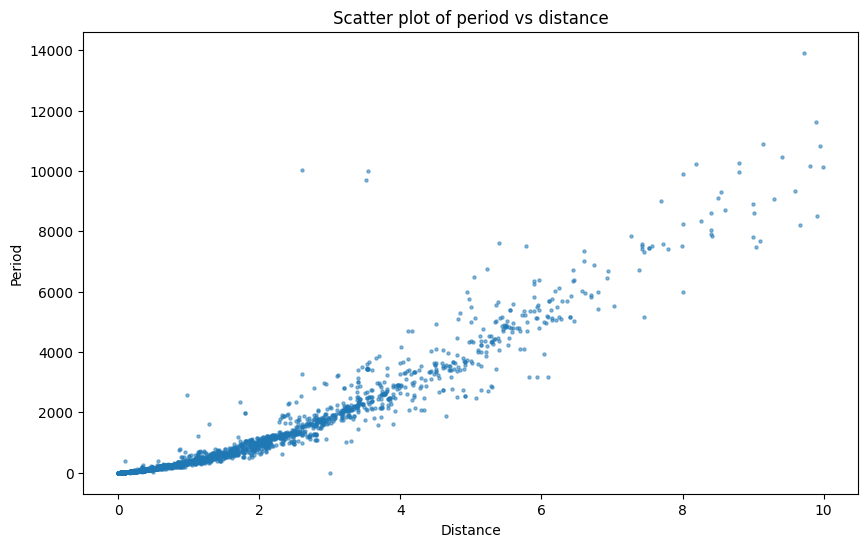

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.title("Scatter plot of period vs distance")
plt.ylabel("Period")
plt.xlabel("Distance")
plt.scatter(x_distance,y_period,marker="o",s=5,alpha=0.5)
plt.show()

In [ ]:
linear=np.polyfit(x_distance,y_period,deg=1)
quad=np.polyfit(x_distance,y_period,deg=2)
x_fit=np.linspace(0, 10, 500)
y_fit_linear=np.polyval(linear,x_fit)
y_fit_quad=np.polyval(quad,x_fit)

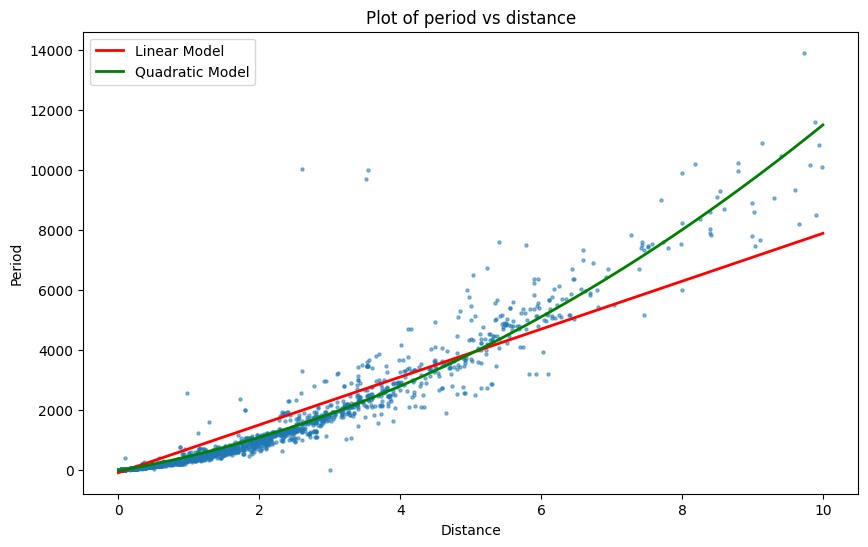

In [ ]:
plt.figure(figsize=(10,6))
plt.title("Plot of period vs distance")
plt.ylabel("Period")
plt.xlabel("Distance")
plt.scatter(x_distance,y_period,marker="o",s=5,alpha=0.5)
plt.plot(x_fit,y_fit_linear,color='red',label='Linear Model',linewidth=2)
plt.plot(x_fit,y_fit_quad,color='green',label='Quadratic Model',linewidth=2)
plt.legend()
plt.show()

In [ ]:
y_pred_linear = np.polyval(linear, x_distance)
y_pred_quad = np.polyval(quad, x_distance)
y_mean = np.mean(y_period)
total_variance = np.sum((y_period - y_mean) ** 2)
residual_linear = np.sum((y_period - y_pred_linear) ** 2)
residual_quad = np.sum((y_period - y_pred_quad) ** 2)
r2_linear = 1 - (residual_linear / total_variance)
r2_quad = 1 - (residual_quad / total_variance)
print(f"Linear Model R^2:    {r2_linear:.4f}")
print(f"Quadratic Model R^2: {r2_quad:.4f}")

Linear Model R^2:    0.9013
Quadratic Model R^2: 0.9496


In [ ]:
coeff_cubic = np.polyfit(x_distance, y_period, deg=3)
y_pred_cubic = np.polyval(coeff_cubic, x_distance)
residual_cubic = np.sum((y_period - y_pred_cubic) ** 2)
r2_cubic = 1 - (residual_cubic / total_variance)
print(f"Cubic Model R^2: {r2_cubic:.4f}")

Cubic Model R^2: 0.9532
